In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

df = pd.read_csv("global_power_plant_database.csv")

df.head()


C:\Users\asus\AppData\Local\Temp\ipykernel_14132\784959824.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)


other_fuel3            34844
other_fuel2            34660
other_fuel1            32992
generation_gwh_2013    28519
generation_gwh_2014    27710
generation_gwh_2015    26733
generation_gwh_2016    25792
generation_gwh_2017    25436
generation_gwh_2018    25299
generation_gwh_2019    25277
dtype: int64

In [5]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")


In [6]:
df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')


In [7]:
df[num_cols].describe()


,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000
mean,163.355148,32.816637,-6.972803,2002.213173,2018.667134,127.988808,154.588104,199.008635,198.005249,192.985207,151.775157,125.547018,125.205717,129.424463,128.846972,132.232824,681.505825
std,489.636072,22.638603,78.405850,17.215166,1.117514,957.739058,1046.708882,1266.608895,1264.941568,1268.250339,1061.662658,911.908039,816.018694,890.157657,891.256782,899.269378,2424.229996
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.067500,8.960000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,28.040000,195.640000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [8]:
top_countries = df['country'].value_counts().head(10)

top_countries


country
USA    9833
CHN    4235
GBR    2751
BRA    2360
FRA    2155
IND    1589
DEU    1309
CAN    1159
ESP     829
RUS     545
Name: count, dtype: int64

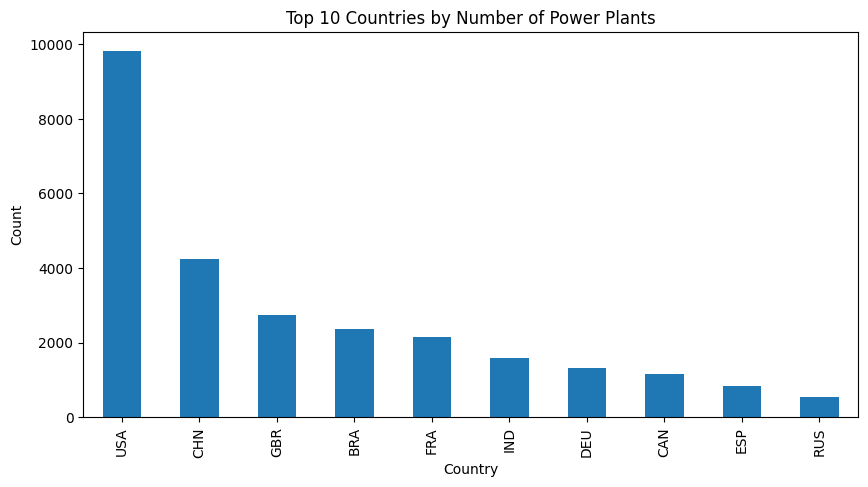

In [9]:
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Number of Power Plants")
plt.ylabel("Count")
plt.xlabel("Country")
plt.show()


In [4]:
fuel_capacity = df.groupby('primary_fuel')['capacity_mw'].apply(np.mean)

fuel_capacity.sort_values(ascending=False)


primary_fuel
Nuclear           2091.855179
Coal               843.579828
Gas                373.449375
Petcoke            202.048125
Hydro              147.171551
Oil                112.878754
Cogeneration        98.731707
Other               84.020000
Geothermal          67.130952
Wave and Tidal      55.220000
Wind                49.224126
Biomass             23.972938
Solar               17.657039
Waste               13.809657
Storage             12.683704
Name: capacity_mw, dtype: float64

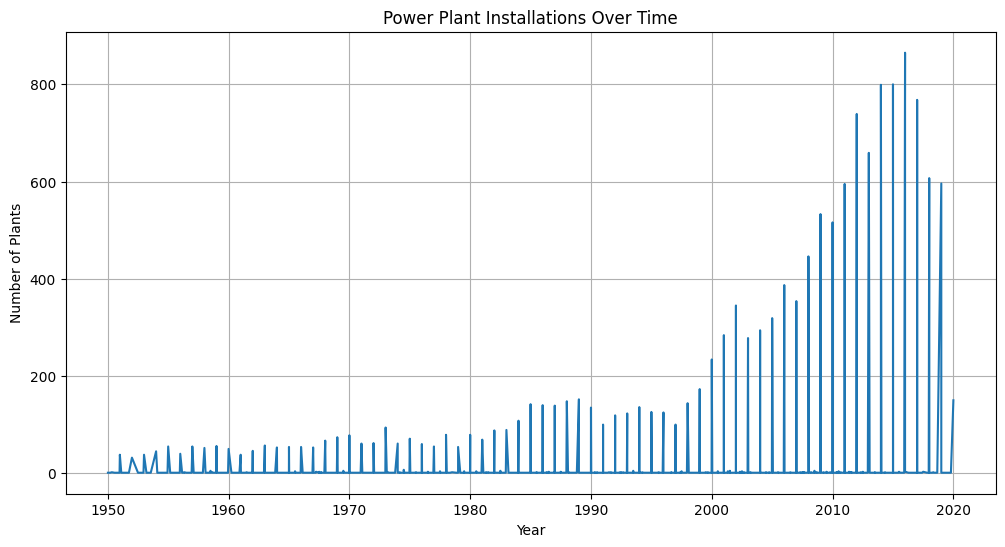

In [7]:
df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')

plants_per_year = df.groupby('commissioning_year').size()
plants_per_year = plants_per_year[plants_per_year.index > 1950]
plt.figure(figsize=(12,6))
plants_per_year.plot()
plt.title("Power Plant Installations Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Plants")
plt.grid(True)
plt.show()



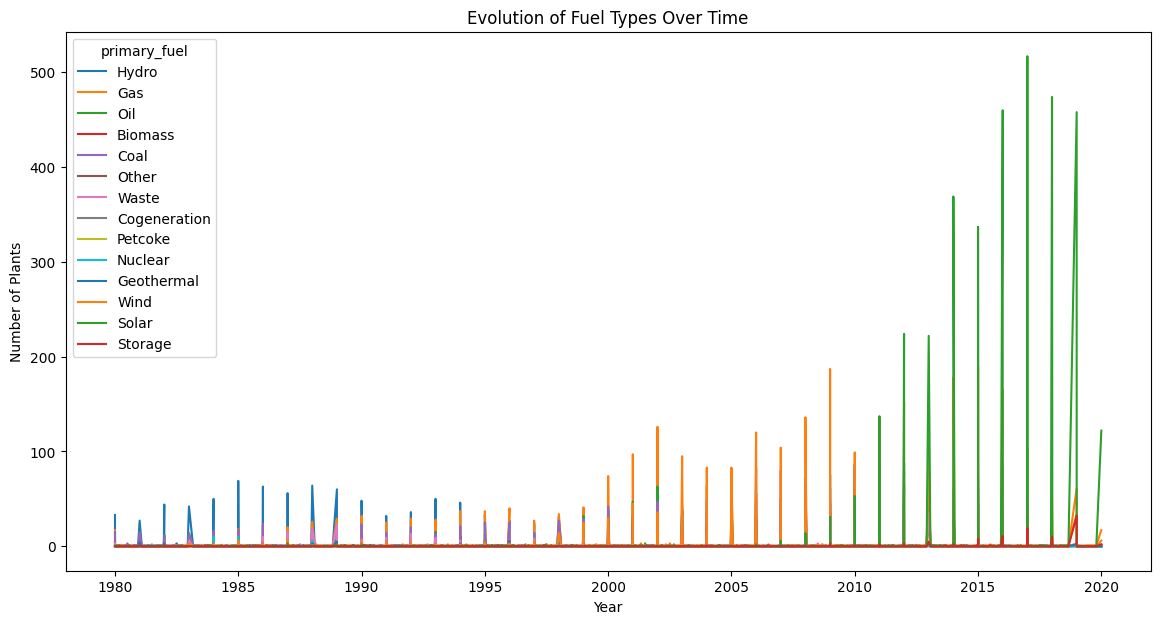

In [8]:
fuel_over_time = df.groupby(['commissioning_year','primary_fuel']).size().unstack().fillna(0)

fuel_over_time.loc[1980:2020].plot(figsize=(14,7))
plt.title("Evolution of Fuel Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Plants")
plt.show()


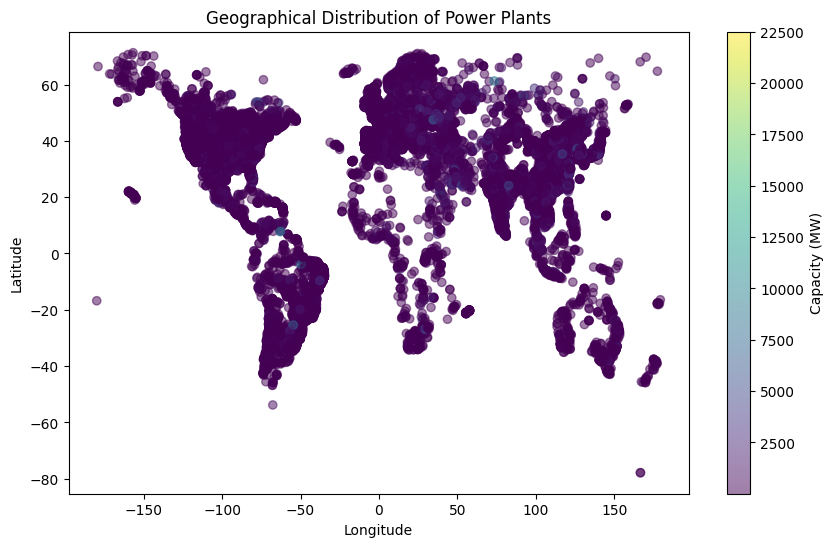

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(df['longitude'], df['latitude'],
            c=df['capacity_mw'],
            cmap='viridis', alpha=0.5)

plt.colorbar(label='Capacity (MW)')
plt.title("Geographical Distribution of Power Plants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [10]:
matrix_data = df[['capacity_mw', 'latitude', 'longitude']].sample(500).values

cov_matrix = np.cov(matrix_data.T)
cov_matrix


array([[ 3.23008765e+05,  2.63543213e+02,  5.39589968e+03],
       [ 2.63543213e+02,  5.62673964e+02, -1.83500534e+02],
       [ 5.39589968e+03, -1.83500534e+02,  6.14729812e+03]])

In [11]:
high_capacity = df[np.array(df['capacity_mw'] > 1000)]
high_capacity.head()


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
36,DZA,Algeria,Hadjret Ennous,WRI1023768,1200.0,36.5767,2.0797,Gas,Oil,NaN,...,NaN,NaN,NaN,NaN,5010.64,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
49,DZA,Algeria,Koudiet Eddraouch,WRI1023769,1200.0,36.8850,8.0778,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,5010.64,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
68,DZA,Algeria,Terga,WRI1023770,1200.0,35.4608,-1.2295,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,5010.64,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
95,ARG,Argentina,ALICURA,ARG0000230,1050.0,-40.5800,-70.7489,Hydro,NaN,NaN,...,2896.84,3621.29,3575.78,3416.89,2896.84,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
141,ARG,Argentina,COSTANERA,ARG0000046,1982.2,-34.6260,-58.3393,Coal,Gas,Other,...,NaN,NaN,NaN,NaN,10273.70,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


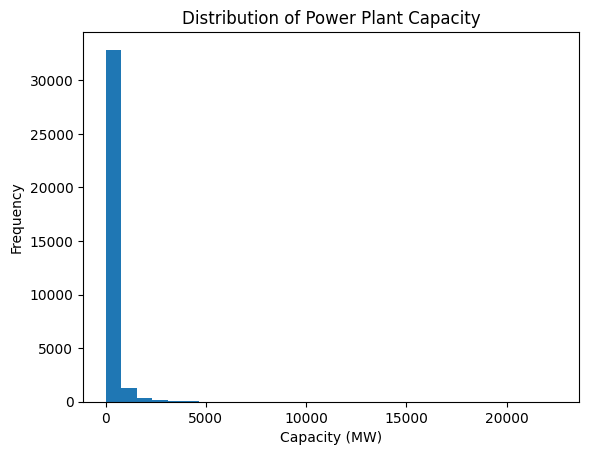

In [12]:
bins = np.linspace(df['capacity_mw'].min(), df['capacity_mw'].max(), 30)

plt.hist(df['capacity_mw'], bins=bins)
plt.title("Distribution of Power Plant Capacity")
plt.xlabel("Capacity (MW)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
'''Global Power Plant Analysis Summary

- The dataset contains power plant data from across the globe.
- Coal and Gas dominate global power generation capacity.
- Power plant installations increased significantly after 1980.
- Renewable energy sources show growth in recent decades.
- Statistical analysis indicates differences in capacity between fuel types.
- Matrix analysis reveals correlations between geography and plant capacity.
'''